In [ ]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.visualization import LogStretch, ImageNormalize
import os
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

In [ ]:
path = "/home/aadam/scratch/SKIRT_TNG/"

In [ ]:
files = []
for d in tqdm(os.listdir(path)):
    for f in glob(os.path.join(path, d, "*.fits")):
        files.append(f)

# Prior sampling

In [ ]:
from scope.models import NCSNpp
from scope.sde import VESDE
from astropy.visualization import ImageNormalize, LogStretch
from scope.score_samplers import EulerMaruyama
from scope.definitions import DEVICE
import torch
import os, json, re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_256_230523001306"
checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_64_230523001203"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_128_230523001212"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_probes_g_64_230604024652"

with open(os.path.join(checkpoint_dir, "model_hparams.json"), "r") as f:
    hyperparameters = json.load(f)
model = NCSNpp(**hyperparameters).to(DEVICE)
paths = glob(os.path.join(checkpoint_dir, "checkpoint*.pt"))
checkpoints = [int(re.findall('[0-9]+', os.path.split(path)[-1])[-1]) for path in paths]
model.eval()
for p in model.parameters(): p.requires_grad = False  # being extra careful for some reasons
model.load_state_dict(torch.load(paths[np.argmax(checkpoints)], map_location=DEVICE))
sde = VESDE(sigma_min=hyperparameters["sigma_min"], sigma_max=hyperparameters["sigma_max"], N=1000)

In [6]:
hyperparameters

{'channels': 1,
 'nf': 128,
 'ch_mult': [2, 2, 2, 2],
 'image_size': 64,
 'activation_type': 'swish',
 'resample_with_conv': True,
 'fir': True,
 'fir_kernel': [1, 3, 3, 1],
 'skip_rescale': True,
 'progressive': 'output_skip',
 'progressive_input': 'input_skip',
 'init_scale': 0.01,
 'fourier_scale': 16.0,
 'resblock_type': 'biggan',
 'combine_method': 'sum',
 'num_res_blocks': 2,
 'dropout': 0,
 'attention': False,
 'beta0': 0.01,
 'beta1': 100000.0,
 'sigma_min': 0.001,
 'sigma_max': 10000.0,
 'dynamic_range': 100000.0,
 'linear_preprocessing': False}

In [7]:
sum([np.prod(p.shape) for p in model.parameters()]) / 1e6

45.557828

In [8]:
# W = 8
# N = 2000
# pixels = 256

W = 64
N = 2000
pixels = 64
sigma = lambda t: sde.marginal_prob(None, t)[1]

sampler = EulerMaruyama(sde=sde, conditioned_score_fn=lambda x, t: model(x, t) / sigma(t).view(-1, 1, 1, 1), N=N)
samples = torch.randn([W, 1, pixels, pixels]).to(DEVICE)
samples = sampler.sample(samples, N, save_last_only=True)

100%|██████████| 2000/2000 [13:33<00:00,  2.46it/s]


# 64

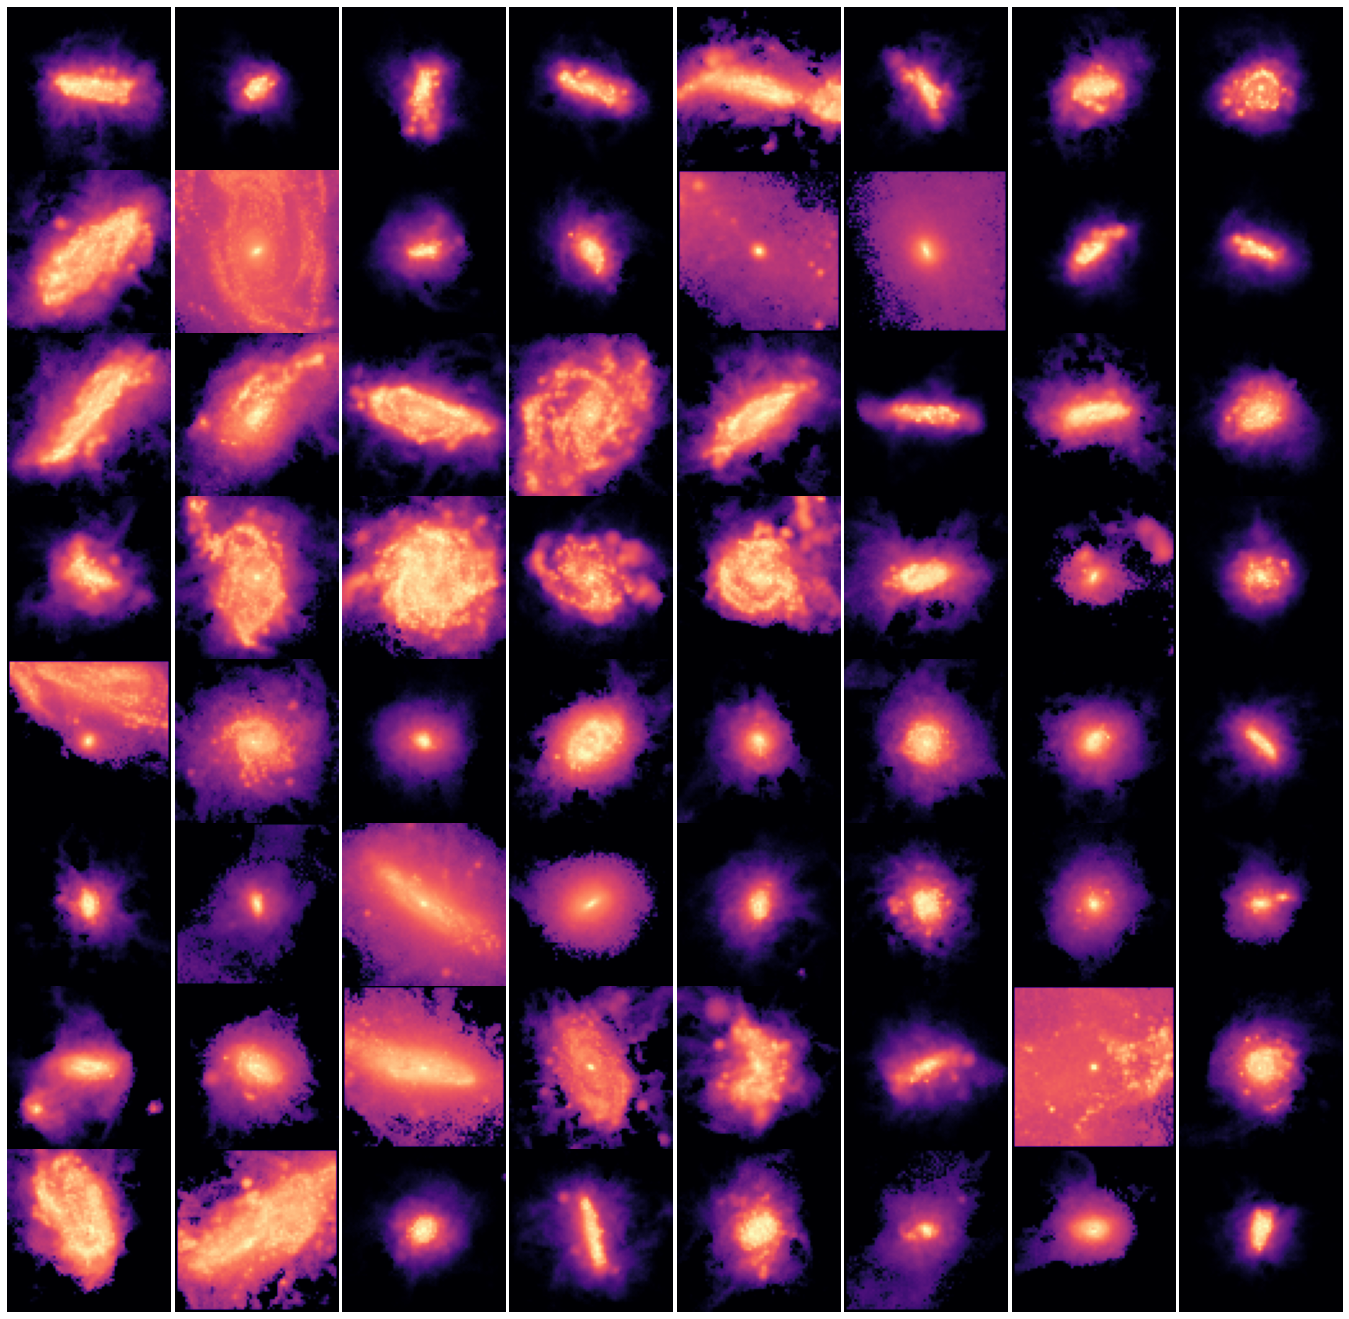

In [26]:
fig, axs = plt.subplots(8, 8, figsize=(24, 24))
for i in range(8):
    for j in range(8):
        k = i * 8 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_illustris_score_64.png")

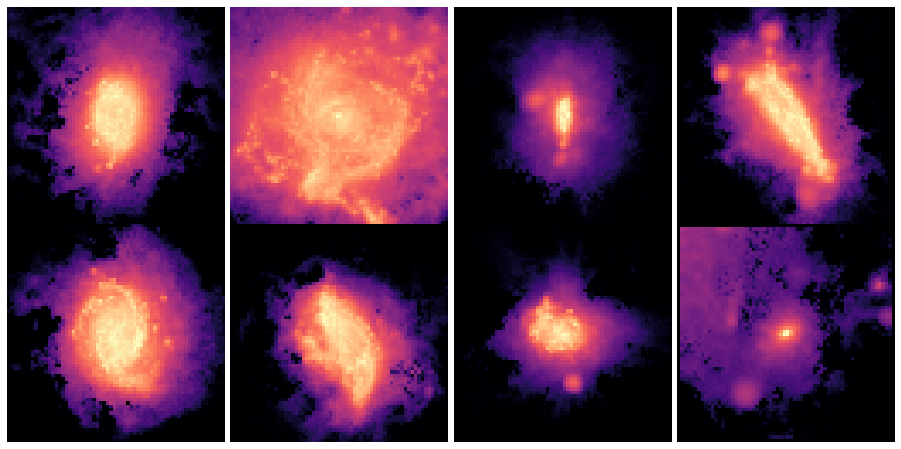

In [14]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# 128

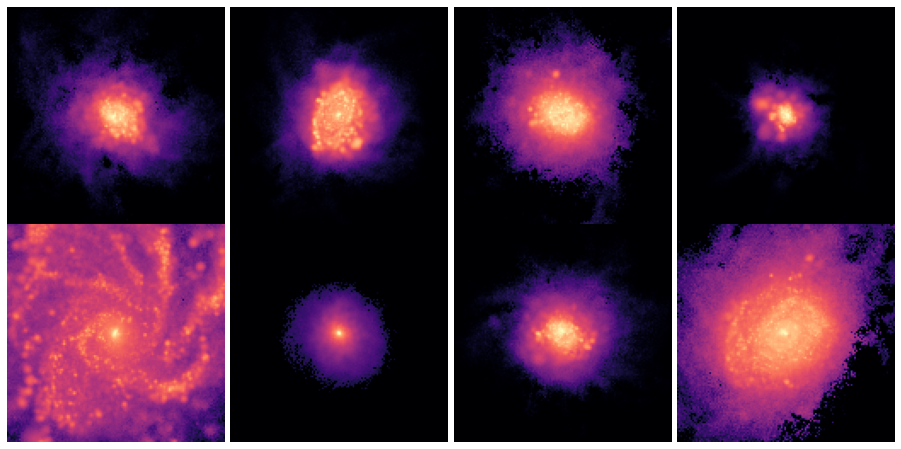

In [28]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# 256

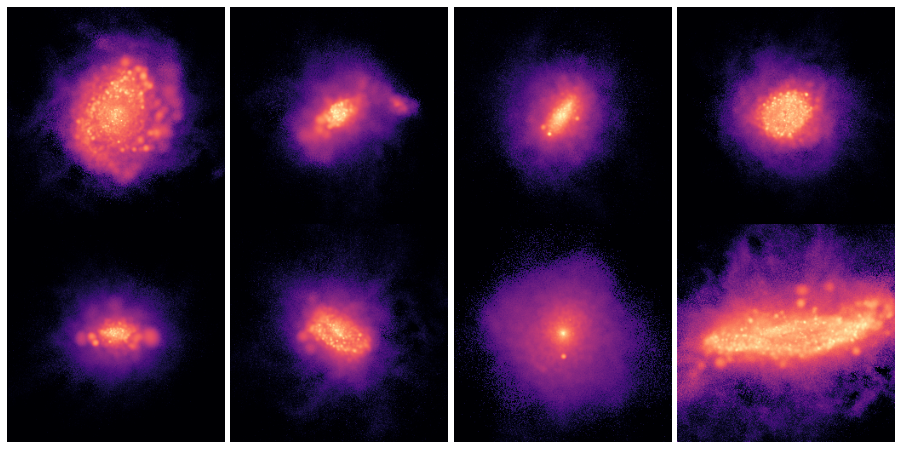

In [10]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# Data

In [24]:
path = "/home/aadam/scratch/skirt64_grizy.h5"
data = h5py.File(path)

def ab_mag_to_jansky_per_arcsec_squared(img):
    return 10**(-(img - 8.9) / 2.5)

def preprocessing(img, dynamic_range=1e5):
    """
    We want the diffusion to happen in log space so that generated images
    strictly have positive flux.

    We use log10(10 micro Jansky / arcsec^2) units instead of AB mag.

    dynamic_range: Sets the decimal value, in Jansky, up to which we hope to model the surface
        brightness. This preprocessing destroys the information below the dynamic range,
        or too faint by our criteria.
    In the end, most pixel values should roughly fall in the range
    [0, log10(dynamic_range)].
    """
    img = ab_mag_to_jansky_per_arcsec_squared(img)
    return np.log(1e5 * img + 1/dynamic_range) / np.log(10.) + np.log10(dynamic_range)

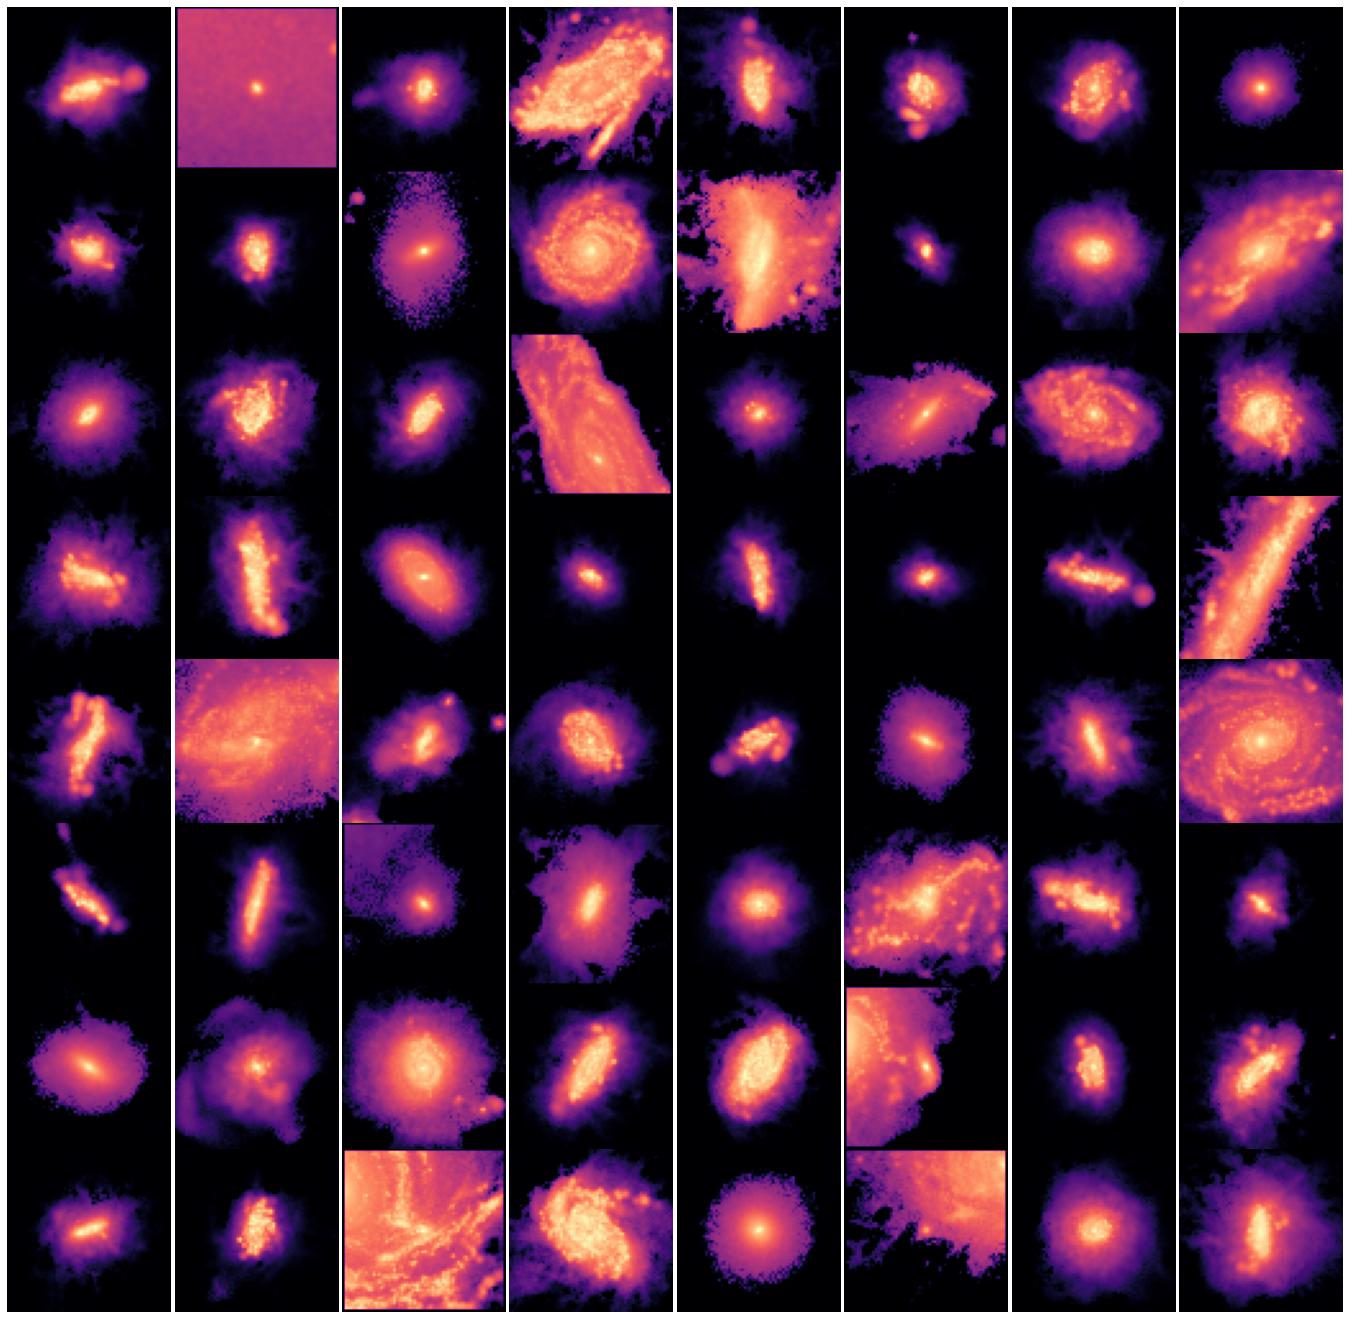

In [27]:
fig, axs = plt.subplots(8, 8, figsize=(24, 24))
for i in range(8):
    for j in range(8):
        k = np.random.randint(data["images"].shape[0])
        axs[i, j].imshow(preprocessing(data["images"][k, 0]), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_illustris_data_64.png")